In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

repos_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/repos/*.parquet'
artifacts_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifacts/*.parquet'
artifact_siblings_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifact_siblings/*.parquet'
mining_runs_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/mining_runs/*.parquet'
skill_features_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/generated_data/skill_features.parquet'
file_agents_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/generated_data/file_agents.parquet'

con = duckdb.connect(database=':memory:')

## Near-duplicates the hash misses

Exact `file_sha` dedup treats only byte-identical files as copies. This notebook measures two looser matches on representative skills (`dedup_primary = 1`): bodies that become identical after dropping front matter and collapsing whitespace, and bodies that are near each other in a TF-IDF space.


#### Whitespace and formatting

Re-hash a normalized body (leading front-matter block removed, lowercased, whitespace collapsed) and count how many extra contents merge.


In [1]:
norm_groups = con.execute(f"""
WITH reps AS (
  SELECT file_sha,
         sha256(trim(regexp_replace(
           lower(regexp_replace(coalesce(content, ''), '^---.*?---', '', 's')),
           '\\s+', ' ', 'g'))) AS norm_hash
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1
), sized AS (
  SELECT norm_hash, COUNT(*) AS n FROM reps GROUP BY 1
)
SELECT (SELECT COUNT(*) FROM reps) AS file_sha_groups,
       COUNT(*) AS norm_hash_groups,
       (SELECT COUNT(*) FROM reps) - COUNT(*) AS extra_merges,
       COUNT(*) FILTER (WHERE n > 1) AS groups_with_2plus,
       SUM(n) FILTER (WHERE n > 1) AS contents_in_merged_groups
FROM sized
""").df()
norm_groups.T.rename(columns={0: "value"})


,value
file_sha_groups,1877981.0
norm_hash_groups,1679607.0
extra_merges,198374.0
groups_with_2plus,98115.0
contents_in_merged_groups,296489.0


Normalization merges 198,374 contents that `file_sha` kept apart: 1,877,981 hashes become 1,679,607 normalized hashes. 98,115 of those hashes cover two or more distinct file hashes (296,489 contents). Formatting-only copies are real, and they are a minority of distinct contents (10.6% collapse into another content).


#### TF-IDF nearest neighbour

For every skill in the sample, the most similar *different* content. The matrix is built on a deterministic 20,000-skill sample (`body_chars >= 200`, ordered by `hash(file_sha)`), because a nearest-neighbour matrix over all 1.8 million readable skills does not fit in memory. A sampled skill's true nearest twin is often outside the sample, so these shares are a floor.


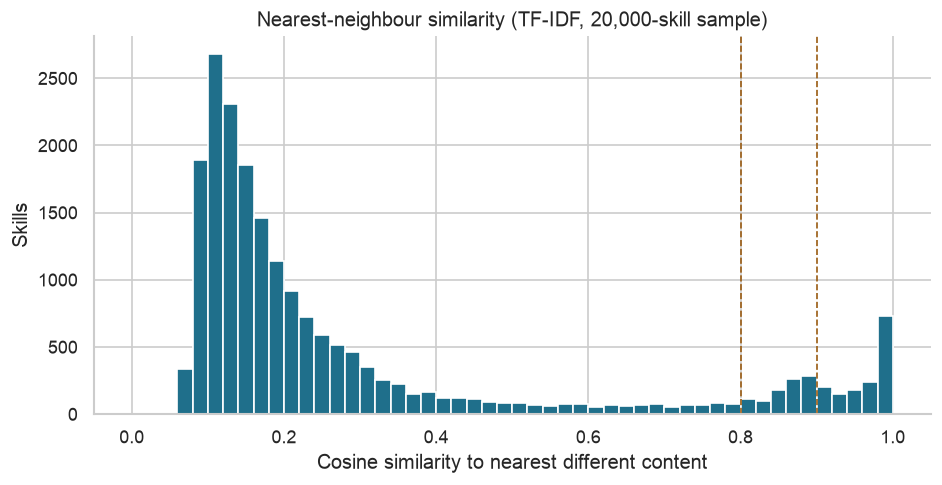

,threshold,skills,%
0,0.95,1053,5.3
1,0.90,1499,7.5
2,0.80,2426,12.1
3,0.70,2769,13.8
4,0.60,3090,15.4


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

base = con.execute(f"""
WITH ids AS (
  SELECT file_sha
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1 AND body_chars >= 200
  ORDER BY hash(file_sha), file_sha
  LIMIT 20000
)
SELECT a.file_sha, a.repo_full_name, a.name, a.body_chars, a.content, r.owner
FROM ids
JOIN read_parquet('{artifacts_path}') a ON a.file_sha = ids.file_sha AND a.dedup_primary = 1
LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
""").df()

def normalize(text):
    text = re.sub(r"^---.*?---", "", text or "", count=1, flags=re.S)
    return re.sub(r"\s+", " ", text.lower()).strip()

base["norm"] = base.content.map(normalize)
X = TfidfVectorizer(min_df=2, max_df=.5, ngram_range=(1, 2), max_features=200_000,
                    sublinear_tf=True).fit_transform(base.norm.str.slice(0, 5000))
dist_, idx_ = NearestNeighbors(n_neighbors=2, metric="cosine").fit(X).kneighbors(X)
base["nn_sim"] = 1 - dist_[:, 1]
base["nn_idx"] = idx_[:, 1]

fig, ax = plt.subplots()
ax.hist(base.nn_sim, bins=50, color=ACCENT)
for t in (.8, .9):
    ax.axvline(t, color="#9A5B12", ls="--", lw=1)
ax.set_xlabel("Cosine similarity to nearest different content")
ax.set_ylabel("Skills")
ax.set_title("Nearest-neighbour similarity (TF-IDF, 20,000-skill sample)")
plt.tight_layout(); plt.show()
nn_thresholds = pd.DataFrame({
    "threshold": [.95, .9, .8, .7, .6],
    "skills": [(base.nn_sim >= t).sum() for t in (.95, .9, .8, .7, .6)],
    "%": [round(100 * (base.nn_sim >= t).mean(), 1) for t in (.95, .9, .8, .7, .6)],
})
nn_thresholds


In [3]:
pairs = base[(base.nn_sim >= .7) & (base.nn_sim < .95)].copy()
pairs["twin_name"] = base.name.iloc[pairs.nn_idx].values
pairs["twin_repo"] = base.repo_full_name.iloc[pairs.nn_idx].values
pairs["twin_owner"] = base.owner.iloc[pairs.nn_idx].values
diff_name = pairs[pairs.name.fillna("").str.lower() != pairs.twin_name.fillna("").str.lower()]
print(f"{len(diff_name):,} of {len(pairs):,} near-duplicate skills have a differently named twin")
diff_name.sort_values("nn_sim", ascending=False)[
    ["nn_sim", "name", "twin_name", "repo_full_name", "twin_repo"]
].head(15).round(2)


780 of 1,716 near-duplicate skills have a differently named twin


,nn_sim,name,twin_name,repo_full_name,twin_repo
3006,0.95,Python Package Build System,pdf-slack,qyb156/PoisonedSkills,qyb156/PoisonedSkills
2563,0.95,customer-feedback,user-story-map,GeorgeQLe/agentic-skills,GeorgeQLe/agentic-skills
10311,0.95,product-expert-209,product-expert-244,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
10307,0.95,product-expert-244,product-expert-209,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
10304,0.95,creative-expert-225,creative-expert-159,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
10303,0.95,creative-expert-159,creative-expert-225,Sandeeprdy1729/skill_galaxy,Sandeeprdy1729/skill_galaxy
16966,0.95,onepagecrm,jazzhr,membranedev/application-skills,membranedev/application-skills
10070,0.95,aid-prototype,aid-document,AndreVianna/aid-methodology,AndreVianna/aid-methodology
10077,0.95,aid-document,aid-prototype,AndreVianna/aid-methodology,AndreVianna/aid-methodology
9467,0.95,owasp-docker-security,owasp-www-project-belva,firebitsbr/OWASP-claudeskills,firebitsbr/OWASP-claudeskills


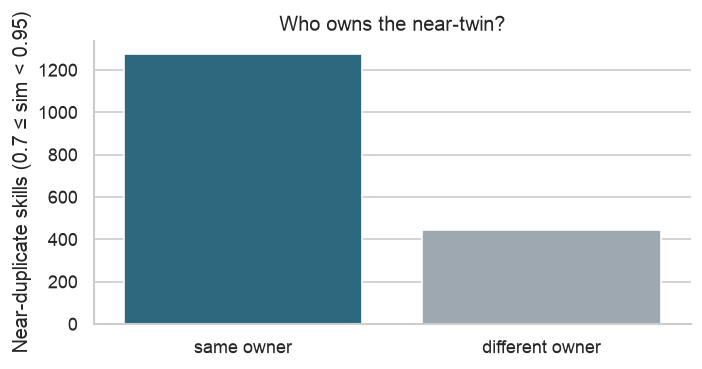

,skills
same owner,1274
different owner,442


In [4]:
split = (pairs.owner == pairs.twin_owner).map({True: "same owner", False: "different owner"}).value_counts()
fig, ax = plt.subplots(figsize=(6, 3.2))
sns.barplot(x=split.index, y=split.values, hue=split.index,
            palette=[ACCENT, GREY][:len(split)], legend=False, ax=ax)
ax.set_ylabel("Near-duplicate skills (0.7 ≤ sim < 0.95)")
ax.set_xlabel("")
ax.set_title("Who owns the near-twin?")
plt.tight_layout(); plt.show()
split.to_frame("skills")


In the 20,000-skill sample, 12.1% have a nearest neighbour at cosine similarity 0.8 or higher. Among pairs in the band 0.7 ≤ similarity < 0.95, 780 of 1,716 (45.5%) use a different front-matter name, so a name match would miss them. 1,274 of those pairs belong to the same owner and 442 to different owners: most near-twins are template series one account republished, and a smaller set is cross-project adaptation.

These rates are a floor. The sample holds about 1.1% of distinct contents, and a skill's closest twin may not have been drawn.


#### Summary


In [5]:
summary = pd.Series({
    "file_sha groups": int(norm_groups.file_sha_groups.iloc[0]),
    "normalized hash groups": int(norm_groups.norm_hash_groups.iloc[0]),
    "extra merges after whitespace normalization": int(norm_groups.extra_merges.iloc[0]),
    "sample size (readable skills)": int(len(base)),
    "sample skills with a near-twin at cosine >= 0.8": f"{(base.nn_sim >= .8).mean():.1%}",
    "near-dup pairs with a different name": int(len(diff_name)),
    "near-dup pairs with the same owner": int((pairs.owner == pairs.twin_owner).sum()),
})
summary.to_frame("value")


,value
file_sha groups,1877981
normalized hash groups,1679607
extra merges after whitespace normalization,198374
sample size (readable skills),20000
sample skills with a near-twin at cosine >= 0.8,12.1%
near-dup pairs with a different name,780
near-dup pairs with the same owner,1274


**Takeaways**
- Exact-hash dedup is reliable for byte-identical files, and it misses copies that differ only by case or whitespace.
- A meaningful share of sampled skills have a near-twin the hash does not merge. Many of those twins are renamed, and most share an owner.
- Names are a poor identity key in both directions: one name covers many texts, and near-duplicate texts often use different names.
